# **04: Model Comparison - ARIMA vs. LSTM**

This notebook compares the performance of the  **ARIMA baseline (03A)** and the **LSTM model (03B)** for short-term disease forecasting in Canada.

The goal is to evaluate how well each model predicts weekly disease cases using held-out test data. The comparison focuses on two key error metrics:

1. **RMSE (Root Mean Squared Error)** - measures how large prediction errors are, with more weight on large mistakes.
2. **MAE (Mean Absolute Error)** - measures the average size of prediction errors.

The ARIMA model was trained separately for each province-disease time series, while the LSTM model was trained across all sequences together. Due to this difference, the comparison is done at the overall test level.

In addition to the overall comparison, this notebook also examines:

- ARIMA performance at the disease level
- LSTM performance across different forecast horizons (1-8 weeks ahead)

These analyses help provide a more complete understanding of how each model behaves and where each one performs better or worse.


## 1. Setup

In [79]:
# Import libraries
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display

warnings.filterwarnings("ignore")

# Mount drive
drive.mount("/content/drive", force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Define Paths & Functions

In [80]:
# Roots
REPO_ROOT = "/content/AAI-590-capstone-canadian-health"
DRIVE_ROOT = "/content/drive/MyDrive/AAI-590-capstone-canadian-health"

# Tables
REPO_TABLES = os.path.join(REPO_ROOT, "reports", "tables")
DRIVE_TABLES = os.path.join(DRIVE_ROOT, "reports", "tables")

# Figures
REPO_FIGURES = os.path.join(REPO_ROOT, "reports", "figures")
DRIVE_FIGURES = os.path.join(DRIVE_ROOT, "reports", "figures")

# Make sure our folders exist
os.makedirs(REPO_TABLES, exist_ok=True)
os.makedirs(DRIVE_TABLES, exist_ok=True)
os.makedirs(REPO_FIGURES, exist_ok=True)
os.makedirs(DRIVE_FIGURES, exist_ok=True)

print("Table directories:")
print(REPO_TABLES)
print(DRIVE_TABLES)

print("\nFigure directories:")
print(REPO_FIGURES)
print(DRIVE_FIGURES)

Table directories:
/content/AAI-590-capstone-canadian-health/reports/tables
/content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables

Figure directories:
/content/AAI-590-capstone-canadian-health/reports/figures
/content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures


In [81]:
# search for file
def file_find(filename, dirs):
    for base_dir in dirs:
        path_full = os.path.join(base_dir, filename)
        if os.path.exists(path_full):
            print(f"Found {filename}: {path_full}")
            return path_full
    raise FileNotFoundError(f"{filename} was not found in {dirs}")

# Save to repo and drive
def save_df(df, filename):
    repo_path = os.path.join(REPO_TABLES, filename)
    drive_path = os.path.join(DRIVE_TABLES, filename)

    df.to_csv(repo_path, index=False)
    df.to_csv(drive_path, index=False)

    print(f"Saved table to repo:  {repo_path}")
    print(f"Saved table to drive: {drive_path}")

# Save figure to both repo and drive (this is for the figures at the end of this notebook)
def save_fig(filename, dpi=300):
    repo_path = os.path.join(REPO_FIGURES, filename)
    drive_path = os.path.join(DRIVE_FIGURES, filename)

    plt.savefig(repo_path, dpi=dpi, bbox_inches="tight")
    plt.savefig(drive_path, dpi=dpi, bbox_inches="tight")

    print(f"Saved figure to repo:  {repo_path}")
    print(f"Saved figure to drive: {drive_path}")

## 3. Load and Validate ARIMA Outputs

In [82]:
# Load arima results from notebook 03A
arima_results_path = file_find(
    "arima_test_results.csv",
    [DRIVE_TABLES, REPO_TABLES]
)

arima_results_df = pd.read_csv(arima_results_path)
arima_results_df.columns = arima_results_df.columns.str.lower().str.strip()

print("ARIMA test results shape:", arima_results_df.shape)
print("ARIMA test results columns:", list(arima_results_df.columns))
display(arima_results_df.head())

Found arima_test_results.csv: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/arima_test_results.csv
ARIMA test results shape: (4, 8)
ARIMA test results columns: ['disease', 'province', 'order', 'test_rmse', 'test_mae', 'aic', 'bic', 'n_test_weeks']


,disease,province,order,test_rmse,test_mae,aic,bic,n_test_weeks
0,influenza,CA-ON,"(1, 0, 0)",2.233511,1.412476,21010.028072,21029.038681,939
1,measles,CA-ON,"(0, 1, 1)",0.006501,0.001978,17551.099156,17563.772416,939
2,whooping-cough,CA-AB,"(0, 1, 1)",0.269657,0.236868,11008.154262,11020.827522,939
3,whooping-cough,CA-ON,"(0, 1, 1)",0.067736,0.047465,6632.471073,6645.144333,939


In [83]:
# Check if diseases are correct
print("Diseases in ARIMA results:")
print(sorted(arima_results_df["disease"].unique()))

Diseases in ARIMA results:
['influenza', 'measles', 'whooping-cough']


In [84]:
# Load ARIMA disease-level summary from notebook 03A
arima_sum_path = file_find(
    "arima_test_summary.csv",
    [DRIVE_TABLES, REPO_TABLES]
)

arima_sum_data = pd.read_csv(arima_sum_path)
arima_sum_data.columns = arima_sum_data.columns.str.lower().str.strip()

print("ARIMA summary shape:", arima_sum_data.shape)
print("ARIMA summary columns:", list(arima_sum_data.columns))
display(arima_sum_data.head())

Found arima_test_summary.csv: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/arima_test_summary.csv
ARIMA summary shape: (3, 5)
ARIMA summary columns: ['disease', 'mae', 'rmse', 'aic', 'bic']


,disease,mae,rmse,aic,bic
0,influenza,1.4125,2.2335,21010.0281,21029.0387
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859


In [85]:
# Check if correct
print("ARIMA disease-level summary:")
display(arima_sum_data)

ARIMA disease-level summary:


,disease,mae,rmse,aic,bic
0,influenza,1.4125,2.2335,21010.0281,21029.0387
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859


In [86]:
# Compute ARIMA performance from province-level test results
arima_total = pd.DataFrame([{
    "model": "ARIMA",
    "mae": round(arima_results_df["test_mae"].mean(), 4),
    "rmse": round(arima_results_df["test_rmse"].mean(), 4),
    "evaluation_scope": "total_test"
}])

print("ARIMAv Performance:")
display(arima_total)

ARIMAv Performance:


,model,mae,rmse,evaluation_scope
0,ARIMA,0.4247,0.6444,total_test


## 4. Load LSTM Outputs

In [87]:
lstm_metrics_path = file_find(
    "lstm_test_metrics.csv",
    [DRIVE_TABLES, REPO_TABLES]
)

lstm_test_data = pd.read_csv(lstm_metrics_path)
lstm_test_data.columns = lstm_test_data.columns.str.lower().str.strip()

print("LSTM test shape:", lstm_test_data.shape)
print("LSTM test columns:", list(lstm_test_data.columns))
display(lstm_test_data.head())

Found lstm_test_metrics.csv: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/lstm_test_metrics.csv
LSTM test shape: (9, 4)
LSTM test columns: ['horizon_week', 'mse', 'rmse', 'mae']


,horizon_week,mse,rmse,mae
0,1,0.291333,0.539753,0.133618
1,2,0.533544,0.730441,0.172226
2,3,0.730919,0.854938,0.201163
3,4,0.895488,0.946302,0.224334
4,5,1.020928,1.010410,0.248779


In [88]:
lstm_cols = {"horizon_week", "mse", "rmse", "mae"}
missing_lstm_cols = lstm_cols - set(lstm_test_data.columns)

if missing_lstm_cols:
    raise ValueError(
        f"LSTM test metrics are missing columns: {missing_lstm_cols}"
    )

lstm_test_data["horizon_week"] = lstm_test_data["horizon_week"].astype(str).str.strip().str.lower()

lstm_overall_row = lstm_test_data[lstm_test_data["horizon_week"] == "overall"].copy()

if lstm_overall_row.empty:
    raise ValueError("File does not contain an 'overall' row.")

lstm_total = pd.DataFrame([{
    "model": "LSTM",
    "rmse": round(float(lstm_overall_row["rmse"].iloc[0]), 4),
    "mae": round(float(lstm_overall_row["mae"].iloc[0]), 4),
    "evaluation_scope": "total_test"
}])

print("LSTM overall performance:")
display(lstm_total)

LSTM overall performance:


,model,rmse,mae,evaluation_scope
0,LSTM,0.9369,0.2286,total_test


## 5. Overall Comparison

In [89]:
compare_AL = pd.concat([arima_total, lstm_total], ignore_index=True)

arima_rmse = compare_AL.loc[compare_AL["model"] == "ARIMA", "rmse"].iloc[0]
arima_mae = compare_AL.loc[compare_AL["model"] == "ARIMA", "mae"].iloc[0]

compare_AL["rmse_imp_vs_arima"] = (
    (arima_rmse - compare_AL["rmse"]) / arima_rmse * 100
).round(2)

compare_AL["mae_imp_vs_arima"] = (
    (arima_mae - compare_AL["mae"]) / arima_mae * 100
).round(2)

compare_AL["better_than_arima_rmse"] = compare_AL["rmse"] < arima_rmse
compare_AL["better_than_arima_mae"] = compare_AL["mae"] < arima_mae

print("Model comparison:")
display(compare_AL)

Model comparison:


,model,mae,rmse,evaluation_scope,rmse_imp_vs_arima,mae_imp_vs_arima,better_than_arima_rmse,better_than_arima_mae
0,ARIMA,0.4247,0.6444,total_test,0.00,0.00,False,False
1,LSTM,0.2286,0.9369,total_test,-45.39,46.17,False,True


The table above shows us that ARIMA achieved a lower RMSE, suggesting more stable predictions with fewer errors. Whereas, LSTM achieves a lower MAE, suggesting better average prediction accuracy but with greater deviations. In short, ARIMA is more reliable for avoiding large forecasting errors, and LSTM is better at capturing overall trends across the dataset.

## 6. ARIMA Disease-Level Analysis

This section ranks disease by ARIMA forecasting performance, where lower MAE and RMSE indicate more accurate predictions and easier to model disease patterns.

In [90]:
# Rank by RMSE
arima_rank_df = arima_sum_data.sort_values(by="rmse", ascending=True)
display(arima_rank_df)

,disease,mae,rmse,aic,bic
1,measles,0.0020,0.0065,17551.0992,17563.7724
2,whooping-cough,0.1422,0.1687,8820.3127,8832.9859
0,influenza,1.4125,2.2335,21010.0281,21029.0387


ARIMA performs best on measles (low error), moderately on whooping-cough, and not good on influenza. This highlights that influenza is the most difficult disease to forecast due to its variability and/or complexity.

## 7. Visualization: ARIMA vs. LSTM Comparison

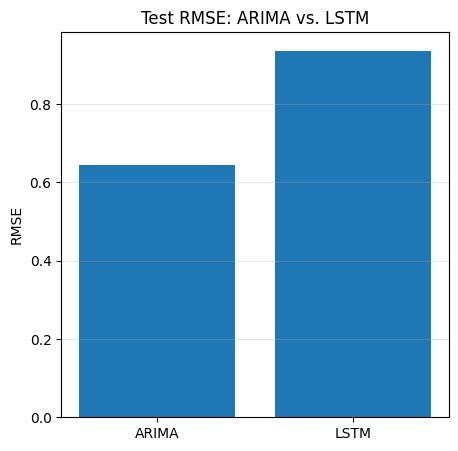

In [91]:
plt.figure(figsize=(5, 5))
plt.bar(compare_AL["model"], compare_AL["rmse"])
plt.title("Test RMSE: ARIMA vs. LSTM")
plt.ylabel("RMSE")
plt.title("Test RMSE: ARIMA vs. LSTM")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [92]:
save_fig("04_fig1_rmse_arima_vs_lstm.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig1_rmse_arima_vs_lstm.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig1_rmse_arima_vs_lstm.png


<Figure size 640x480 with 0 Axes>

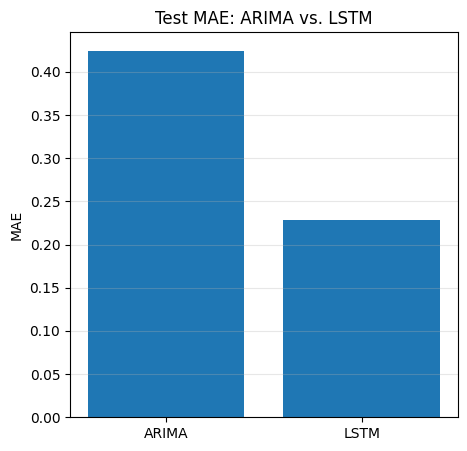

In [93]:
plt.figure(figsize=(5, 5))
plt.bar(compare_AL["model"], compare_AL["mae"])
plt.title("Test MAE: ARIMA vs. LSTM")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [94]:
save_fig("04_fig2_mae_arima_vs_lstm.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig2_mae_arima_vs_lstm.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig2_mae_arima_vs_lstm.png


<Figure size 640x480 with 0 Axes>

## 8. Visualization: ARIMA Disease-Level Performance

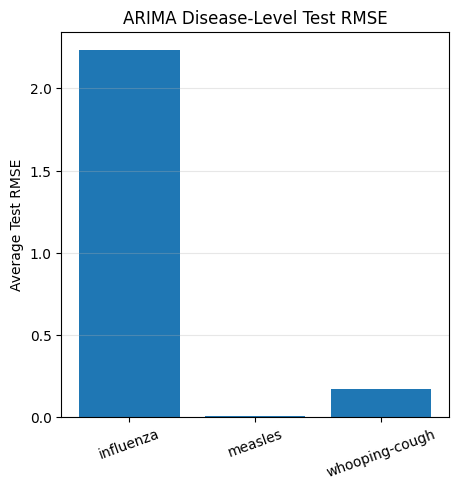

In [95]:
plt.figure(figsize=(5, 5))
plt.title("ARIMA Disease-Level Test RMSE")
plt.bar(arima_sum_data["disease"], arima_sum_data["rmse"])
plt.ylabel("Average Test RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [96]:
save_fig("04_fig3_arima_disease_level_rmse.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig3_arima_disease_level_rmse.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig3_arima_disease_level_rmse.png


<Figure size 640x480 with 0 Axes>

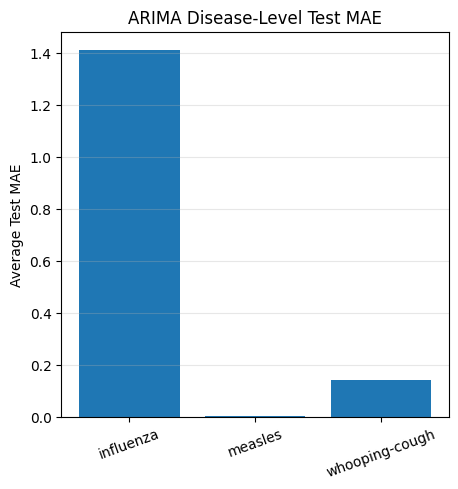

In [97]:
plt.figure(figsize=(5, 5))
plt.bar(arima_sum_data["disease"], arima_sum_data["mae"])
plt.title("ARIMA Disease-Level Test MAE")
plt.ylabel("Average Test MAE")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [98]:
save_fig("04_fig4_arima_disease_level_mae.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig4_arima_disease_level_mae.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig4_arima_disease_level_mae.png


<Figure size 640x480 with 0 Axes>

## 9. Visualization: LSTM Performance by Forecast Horizon

In [99]:
lstm_horizon = lstm_test_data[lstm_test_data["horizon_week"] != "overall"].copy()
lstm_horizon["horizon_week"] = lstm_horizon["horizon_week"].astype(int)
lstm_horizon = lstm_horizon.sort_values("horizon_week")

print("LSTM per horizon test metrics:")
display(lstm_horizon)

LSTM per horizon test metrics:


,horizon_week,mse,rmse,mae
0,1,0.291333,0.539753,0.133618
1,2,0.533544,0.730441,0.172226
2,3,0.730919,0.854938,0.201163
3,4,0.895488,0.946302,0.224334
4,5,1.020928,1.010410,0.248779
5,6,1.121356,1.058941,0.267903
6,7,1.188155,1.090025,0.285943
7,8,1.240377,1.113722,0.295035


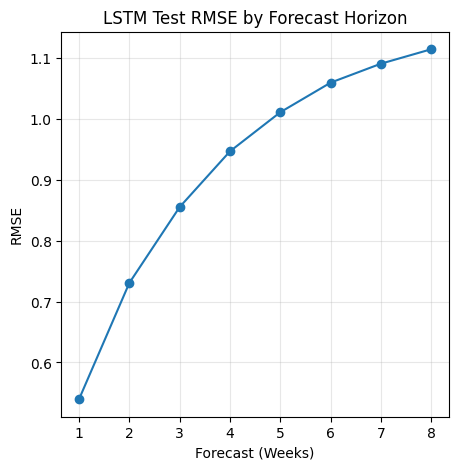

In [100]:
plt.figure(figsize=(5, 5))
plt.plot(lstm_horizon["horizon_week"], lstm_horizon["rmse"], marker="o")
plt.title("LSTM Test RMSE by Forecast Horizon")
plt.xlabel("Forecast (Weeks)")
plt.ylabel("RMSE")
plt.xticks(lstm_horizon["horizon_week"])
plt.grid(alpha=0.3)
plt.show()

In [101]:
save_fig("04_fig5_lstm_test_rmse_by_horizon.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig5_lstm_test_rmse_by_horizon.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig5_lstm_test_rmse_by_horizon.png


<Figure size 640x480 with 0 Axes>

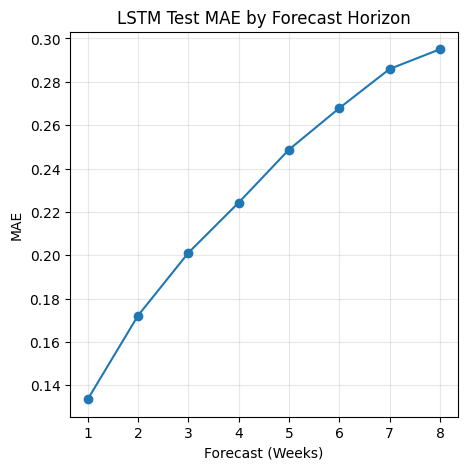

In [102]:
plt.figure(figsize=(5, 5))
plt.plot(lstm_horizon["horizon_week"], lstm_horizon["mae"], marker="o")
plt.title("LSTM Test MAE by Forecast Horizon")
plt.xlabel("Forecast (Weeks)")
plt.ylabel("MAE")
plt.xticks(lstm_horizon["horizon_week"])
plt.grid(alpha=0.3)
plt.show()

In [103]:
save_fig("04_fig6_lstm_test_mae_by_horizon.png")

Saved figure to repo:  /content/AAI-590-capstone-canadian-health/reports/figures/04_fig6_lstm_test_mae_by_horizon.png
Saved figure to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/figures/04_fig6_lstm_test_mae_by_horizon.png


<Figure size 640x480 with 0 Axes>

## 10. Export Final Tables

In [104]:
save_df(compare_AL, "model_comparison.csv")
save_df(arima_sum_data, "arima_disease_level_summary.csv")
save_df(lstm_test_data, "cleaned_lstm_test_metrics.csv")

Saved table to repo:  /content/AAI-590-capstone-canadian-health/reports/tables/model_comparison.csv
Saved table to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/model_comparison.csv
Saved table to repo:  /content/AAI-590-capstone-canadian-health/reports/tables/arima_disease_level_summary.csv
Saved table to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/arima_disease_level_summary.csv
Saved table to repo:  /content/AAI-590-capstone-canadian-health/reports/tables/cleaned_lstm_test_metrics.csv
Saved table to drive: /content/drive/MyDrive/AAI-590-capstone-canadian-health/reports/tables/cleaned_lstm_test_metrics.csv


In [105]:
print("\nFinal Model Performance:")

for _, row in compare_AL.iterrows():
    print(f"{row['model']}: RMSE = {row['rmse']}, MAE = {row['mae']}")


Final Model Performance:
ARIMA: RMSE = 0.6444, MAE = 0.4247
LSTM: RMSE = 0.9369, MAE = 0.2286


## 11. Interpretation

This section evaluates the quantitative performance of the ARIMA baseline and LSTM model for short-term disease forecasting in Canada.

### Overall Model Performance
The comparison is based on the overall held-out test set, using RMSE and MAE as the evaluation metrics.

The ARIMA and LSTM models were developed in different ways. ARIMA was trained separetely for each province-disease time series, so it works as a local model. Whereas, LSTM was trained across all sequences together, working as a global model and learning patterns shared across provinces and diseases.

As a result, the ARIMA results are at the disease level, while the LSTM results are only available as overall and forecast horizon summaries.

### Interpretation of ARIMA Results
The ARIMA model produced separate forecasts for each province-disease pair, which makes it useful for understanding local disease patterns.

**Strengths**
- Captures local time-series patterns well
- Easy to interpret
- Provides a transparent baseline

**Limitations**
- Does not share information across provinces or diseases.
- Assumes mainly linear relationships.
- May not handle complex outbreak behavior as well.

The disease-level results show that some disease are much easier to forecast than others. ARIMA performs best on measles, moderately on whooping-cough, and not so well on influzena. This suggests that influenza is the hardest disease to predict, likely because it has stronger seasonal patterns and more variations across time.

### Interpretation of LSTM Results
The LSTM model was trained on all sequences together and evaluated using both overall test metrics and per horizon results.

The results highlight that LSTM captures broad patterns across the full dataset, but its error increases as the forecast horizon gets longer. Both RMSE and MAE rise from week 1 to week 8, which means the model becomes less accurate as it predicts further into the future.

Nonetheless, LSTM achieves a lower overall MAE than ARIMA, meaning its predictions are closer to the true values on average.

### Comparison
The results show a clear tradeoff between the two models.

ARIMA has the lower RMSE (**0.6444 vs. 0.9369**), which means it makes fewer large mistakes and gives more stable predictions overall.

LSTM has the lower MAE (**0.2286 vs. 0.4247**), which means its predictions are more accurate on average, even though it makes some larger errors that raise its RMSE.

In short, ARIMA is more consistent, whereas LSTM is better at average prediction but less reliable when errors become large.

### Limitations
One important limitation is that the two models are not being evaluated at the same level.
- ARIMA results are available by province and disease.
- LSTM results are only available overall and by forecast horizon.

Due to this, the comparison in this notebook is limited to the overall test level. To make a more detailed comparison in the future, the LSTM model would need to output test metrics by province and disease, just like ARIMA.
